# Ball and Box contact forces

In [8]:
import mujoco
import mediapy as media
import numpy as np
import matplotlib.pyplot as plt

""

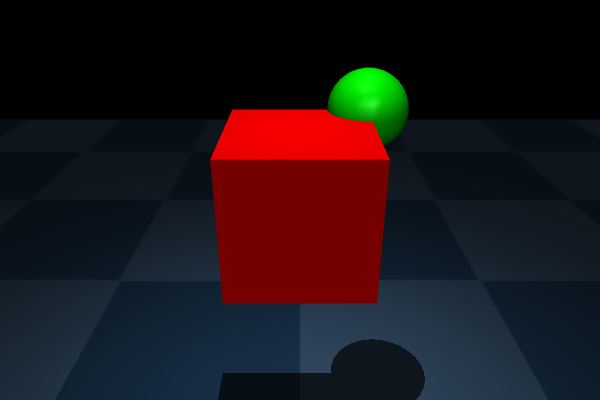

In [2]:
model = mujoco.MjModel.from_xml_path('Box_Sphere_Contact.xml')
data = mujoco.MjData(model)
height = 400
width = 600

with mujoco.Renderer(model, height, width) as renderer:
    mujoco.mj_forward(model, data)
    renderer.update_scene(data, "fixed")

    media.show_image(renderer.render())

In [7]:
n_frames = 200
height = 240
width = 320
frames = []

# show contact frames and forces, make body transparent
options =  mujoco.MjvOption()
mujoco.mjv_defaultOption(options)
options.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
options.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True
options.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = True

# tweak scales of contact visualization elements
model.vis.scale.contactwidth = 0.1
model.vis.scale.contactheight = 0.03
model.vis.scale.forcewidth = 0.05
model.vis.map.force = 0.3

# random initial rotational velocity
mujoco.mj_resetData(model, data)
data.qvel[3:6] = 5*np.random.randn(3)

# Simulate and display Video
with mujoco.Renderer(model, height, width) as renderer:
    for i in range(n_frames):
        while data.time < i / 120.0: #1/4 real time
            mujoco.mj_step(model, data)
        renderer.update_scene(data, "track", options)
        frame = renderer.render()
        frames.append(frame)
media.show_video(frames, fps=30)



This browser does not support the video tag.


# Analasis of contact forces

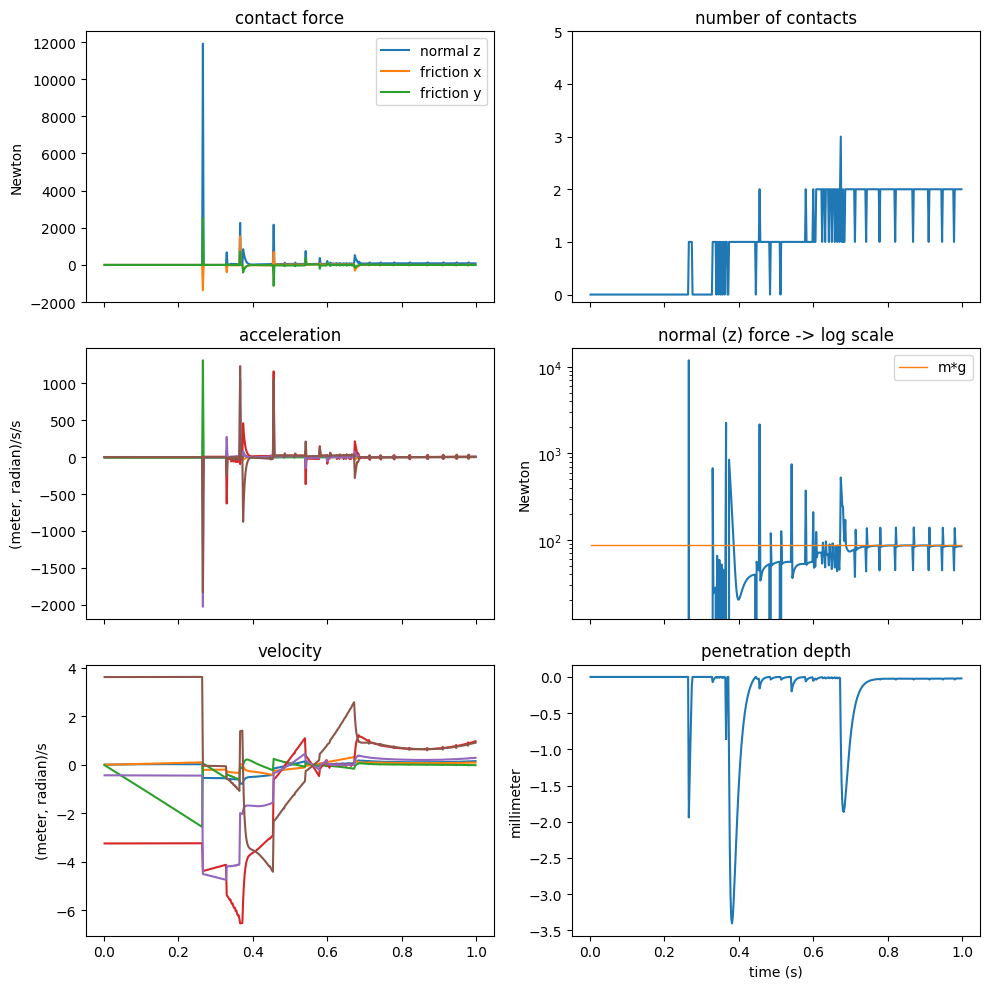

In [13]:
n_steps = 499

# allocate
sim_time = np.zeros(n_steps)
ncon = np.zeros(n_steps)
force = np.zeros((n_steps,3))
velocity = np.zeros((n_steps,model.nv))
penetration = np.zeros(n_steps)
acceleration = np.zeros((n_steps, model.nv))
forcetorque = np.zeros(6)

# random initial rotational velocity
mujoco.mj_resetData(model, data)
data.qvel[3:6] = 5*np.random.randn(3)

# Simulate and save the data
for i in range(n_steps):
    mujoco.mj_step(model, data)
    sim_time[i] = data.time
    ncon[i] = data.ncon
    velocity[i] = data.qvel[:]
    acceleration[i] = data.qacc[:]
    # iterate over active contacts, save force and distance
    for j, c in enumerate(data.contact):
        mujoco.mj_contactForce(model, data, j, forcetorque)
        force[i] += forcetorque[0:3]
        penetration[i] = min(penetration[i], c.dist)
        # we can also do 
        # force[i] += data.qfrc_constraint[0:3]
        # do you see why?
# plot the data
_, ax = plt.subplots(3,2, sharex= True, figsize=(10,10))

lines = ax[0,0].plot(sim_time, force)
ax[0,0].set_title('contact force')
ax[0,0].set_ylabel('Newton')
ax[0,0].legend(iter(lines), ('normal z', 'friction x', 'friction y'))

ax[1,0].plot(sim_time, acceleration)
ax[1,0].set_title('acceleration')
ax[1,0].set_ylabel('(meter, radian)/s/s')

ax[2,0].plot(sim_time, velocity)
ax[2,0].set_title('velocity')
ax[2,0].set_ylabel('(meter, radian)/s')

ax[0,1].plot(sim_time, ncon)
ax[0,1].set_title('number of contacts')
ax[0,1].set_yticks(range(6))

ax[1,1].plot(sim_time, force[:,0])
ax[1,1].set_yscale('log')
ax[1,1].set_title('normal (z) force -> log scale')
ax[1,1].set_ylabel('Newton')
z_gravity = -model.opt.gravity[2]
mg = model.body("box_and_sphere").mass[0]*z_gravity
mg_line = ax[1,1].plot(sim_time, np.ones(n_steps)*mg, label='m*g', linewidth=1)
ax[1,1].legend()

ax[2,1].plot(sim_time, penetration*1e3)
ax[2,1].set_title('penetration depth')
ax[2,1].set_ylabel('millimeter')
ax[2,1].set_xlabel('time (s)')

plt.tight_layout()



# Playing with friction

In [36]:
n_frames = 60
height = 300
width = 300
frames = []

# load
model = mujoco.MjModel.from_xml_path('box.xml')
data = mujoco.MjData(model)

# Simulate and display Video
with mujoco.Renderer(model, height, width) as renderer:
    mujoco.mj_resetData(model, data)
    for i in range(n_frames):
        while data.time < i / 30.0:
            mujoco.mj_step(model, data)
        renderer.update_scene(data, "y")
        frame = renderer.render()
        frames.append(frame)
media.show_video(frames, fps=30)

This browser does not support the video tag.
